In [1]:
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Directories
figure_dir = 'figures'
data_path="/media/NAS2/ISMIP7/share_with_modellers"


# Constants
yearlen = 365.14*24*60*60 # seconds per year
ice_density = 918 # kg/m3

cvt = 8000**2  / 1e12 # kg/m2/a to Gt/a

# Prepare target for term 2

In [4]:
melt_obs = xr.load_dataset(os.path.join(data_path, 'parameterisations','melt_paolo_err_adusumilli_ismip8km.nc')) # Field

# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path, 'parameterisations',"BFRN_ismip8km_v2.nc"))
nBins = 10

# Load BedMap3
bed = xr.load_dataset(os.path.join(data_path, "topography", "bedmap3_ismip_8km.nc"))
mask = bed.floating_frac>0.5

In [5]:
# Observed melt in Gt/a per buttressing bin, observed melt is
# "sample_size"-times randomly sampled assuming normal distribution
t2_obs_mean = (
    melt_obs['melt_mean']
    .where(mask, np.nan)
    .groupby(bfrn['BFRN_bins'])
    .sum()
    * cvt
)
t2_obs_sigma = (
    melt_obs['melt_mean_err']
    .where(mask, np.nan)
    .groupby(bfrn['BFRN_bins'])
    .sum()
    * cvt
)

In [6]:
ds = xr.merge([t2_obs_mean, t2_obs_sigma])
ds

<xarray.Dataset> Size: 240B
Dimensions:        (BFRN_bins: 10)
Coordinates:
  * BFRN_bins      (BFRN_bins) float64 80B 0.0 1.0 2.0 3.0 ... 6.0 7.0 8.0 9.0
Data variables:
    melt_mean      (BFRN_bins) float64 80B 128.6 6.936 15.32 ... 113.8 284.7
    melt_mean_err  (BFRN_bins) float64 80B 236.6 34.63 39.96 ... 52.99 50.95

<ErrorbarContainer object of 3 artists>

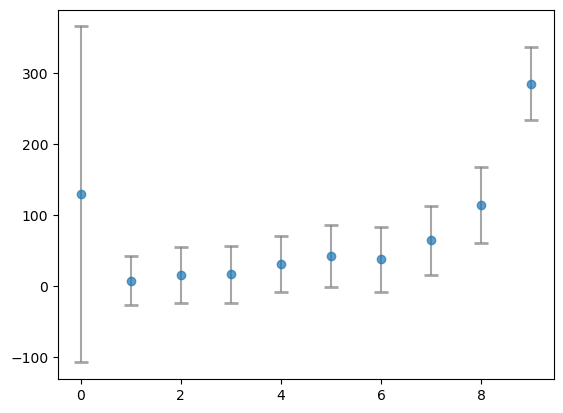

In [7]:
plt.errorbar(range(len(ds.BFRN_bins)), 
            ds.melt_mean, 
            xerr=None, 
            yerr=ds.melt_mean_err,
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')

In [15]:
ds.to_netcdf(os.path.join(data_path, 'parameterisations',"melt_target_term2.nc"))

# Prepare melt target for term 3

In [46]:
# Ocean Modelling 

# Load imbie2 basins as used on ISMIP
basins = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins = basins.rename({'basinNumber':'basins'}) # basins start at 0

def calc_ocean_modelling_melt_target(model_names,basins):
    ensembles_mean = []
    ensembles_sigma = []
    
    for j,model in enumerate(model_names):
        print(model)
        try:
            tmp = xr.load_dataset(os.path.join(data_path,"parameterisations", "Ocean_Modelling_Data",model+"m.nc"))
        except:
            # FIXME remove once datasets are finalised!!!
            tmp = xr.load_dataset("/media/NAS2/ISMIP7/Tocheck/output/"+model+"m.nc")
        obs_mean = (
            tmp['melt_rate']
            .where(mask, np.nan)
            .groupby(basins)
            .mean(skipna=True)
            # as unit is kg/m2/a
        )
        # Note that this assumes errors to be uncorrelated
        # which is the most conservative approach
        obs_sigma = np.sqrt(
            (tmp['melt_rate_uncert'].where(mask, np.nan) ** 2)
            .groupby(basins)
            .mean(skipna=True)
        )
        
        obs_mean = obs_mean.expand_dims({"model": np.array([j])})
        ensembles_mean.append(obs_mean)
        obs_sigma = obs_sigma.expand_dims({"model": np.array([j])})
        ensembles_sigma.append(obs_sigma)
        
    result_mean = xr.concat(ensembles_mean, dim='model')
    result_sigma = xr.concat(ensembles_sigma, dim='model')
    return xr.merge([result_mean, result_sigma])


# create ensemble for ocean modelling data

# FIXME: missing Jourdain, Haid data

model_names = ['Mathiot23_cold_', "TimmermannUndGoeller2017_cold_", "Naughten_FESOM_ACCESS_cold_", "Naughten_FESOM_MMM_cold_",
              'Naughten_MITgcmASE_ens01_cold_', 'Naughten_MITgcmASE_ens02_cold_', 'Naughten_MITgcmASE_ens03_cold_', 
               'Naughten_MITgcmASE_ens04_cold_','Naughten_MITgcmASE_ens05_cold_', 'Naughten_MITgcmASE_ens06_cold_', 
               'Naughten_MITgcmASE_ens07_cold_', 'Naughten_MITgcmASE_ens08_cold_', 'Naughten_MITgcmASE_ens09_cold_', 
               'Naughten_MITgcmASE_ens10_cold_', 'Naughten_MITgcmWS_1pctCO2_cold_', 'Naughten_MITgcmWS_4xCO2_cold_' ]
cold_target = calc_ocean_modelling_melt_target(model_names,basins.basins)
cold_target = cold_target.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])

model_names = [name.replace('cold', 'warm') for name in model_names] 
warm_target = calc_ocean_modelling_melt_target(model_names,basins.basins)
warm_target = warm_target.assign_coords(model=["mathiot", "timmermann", "naughten_ais_1", "naughten_ais_2",
                                              "naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
                                              "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
                                              "naughten_ase_9","naughten_ase_10","naughten_ws_1", "naughten_ws_2"])


# set outside of Weddell Sea to nan
for model in ["timmermann","naughten_ws_1", "naughten_ws_2"]:
    cold_target = cold_target.where( (cold_target.model!=model )| (cold_target.basins == 14), np.nan)
    warm_target = warm_target.where( (warm_target.model!=model )| (warm_target.basins == 14), np.nan)


# set outside of ASE to nan
for model in ["naughten_ase_1","naughten_ase_2","naughten_ase_3","naughten_ase_4",
             "naughten_ase_5","naughten_ase_6","naughten_ase_7","naughten_ase_8",
             "naughten_ase_9","naughten_ase_10",]:
    cold_target = cold_target.where( (cold_target.model!=model )| (cold_target.basins == 9), np.nan)
    warm_target = warm_target.where( (warm_target.model!=model )| (warm_target.basins == 9), np.nan)

Mathiot23_cold_
TimmermannUndGoeller2017_cold_
Naughten_FESOM_ACCESS_cold_
Naughten_FESOM_MMM_cold_
Naughten_MITgcmASE_ens01_cold_
Naughten_MITgcmASE_ens02_cold_
Naughten_MITgcmASE_ens03_cold_
Naughten_MITgcmASE_ens04_cold_
Naughten_MITgcmASE_ens05_cold_
Naughten_MITgcmASE_ens06_cold_
Naughten_MITgcmASE_ens07_cold_
Naughten_MITgcmASE_ens08_cold_
Naughten_MITgcmASE_ens09_cold_
Naughten_MITgcmASE_ens10_cold_
Naughten_MITgcmWS_1pctCO2_cold_
Naughten_MITgcmWS_4xCO2_cold_
Mathiot23_warm_
TimmermannUndGoeller2017_warm_
Naughten_FESOM_ACCESS_warm_
Naughten_FESOM_MMM_warm_
Naughten_MITgcmASE_ens01_warm_
Naughten_MITgcmASE_ens02_warm_
Naughten_MITgcmASE_ens03_warm_
Naughten_MITgcmASE_ens04_warm_
Naughten_MITgcmASE_ens05_warm_
Naughten_MITgcmASE_ens06_warm_
Naughten_MITgcmASE_ens07_warm_
Naughten_MITgcmASE_ens08_warm_
Naughten_MITgcmASE_ens09_warm_
Naughten_MITgcmASE_ens10_warm_
Naughten_MITgcmWS_1pctCO2_warm_
Naughten_MITgcmWS_4xCO2_warm_


([<matplotlib.axis.XTick at 0x7ef91c6b2010>,
 [Text(0, 0, "('mathiot', 0)"),
  Text(1, 0, "('mathiot', 1)"),
  Text(2, 0, "('mathiot', 2)"),
  Text(3, 0, "('mathiot', 3)"),
  Text(4, 0, "('mathiot', 4)"),
  Text(5, 0, "('mathiot', 5)"),
  Text(6, 0, "('mathiot', 6)"),
  Text(7, 0, "('mathiot', 7)"),
  Text(8, 0, "('mathiot', 8)"),
  Text(9, 0, "('mathiot', 9)"),
  Text(10, 0, "('mathiot', 10)"),
  Text(11, 0, "('mathiot', 11)"),
  Text(12, 0, "('mathiot', 12)"),
  Text(13, 0, "('mathiot', 13)"),
  Text(14, 0, "('mathiot', 14)"),
  Text(15, 0, "('mathiot', 15)"),
  Text(16, 0, "('timmermann', 14)"),
  Text(17, 0, "('naughten_ais_1', 0)"),
  Text(18, 0, "('naughten_ais_1', 1)"),
  Text(19, 0, "('naughten_ais_1', 2)"),
  Text(20, 0, "('naughten_ais_1', 3)"),
  Text(21, 0, "('naughten_ais_1', 4)"),
  Text(22, 0, "('naughten_ais_1', 5)"),
  Text(23, 0, "('naughten_ais_1', 6)"),
  Text(24, 0, "('naughten_ais_1', 7)"),
  Text(25, 0, "('naughten_ais_1', 8)"),
  Text(26, 0, "('naughten_ais_1', 

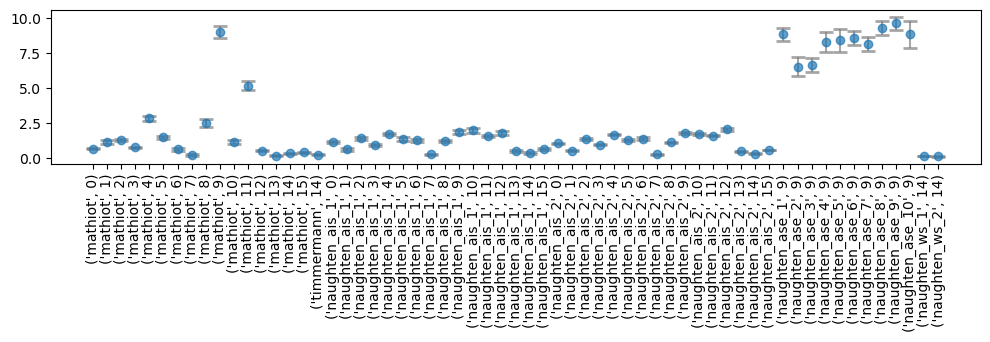

In [50]:
ds_stack = cold_target.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')

plt.figure(figsize=(12,2))
plt.clf()

plt.errorbar(range(len(ds_stack.modelbasin)), 
            ds_stack.melt_rate/ice_density, 
            xerr=None, yerr=ds_stack.melt_rate_uncert.dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
plt.xticks(range(len(ds_stack.modelbasin.values)),ds_stack.modelbasin.values, rotation=90)

([<matplotlib.axis.XTick at 0x7ef917e4f1d0>,
 [Text(0, 0, "('mathiot', 0)"),
  Text(1, 0, "('mathiot', 1)"),
  Text(2, 0, "('mathiot', 2)"),
  Text(3, 0, "('mathiot', 3)"),
  Text(4, 0, "('mathiot', 4)"),
  Text(5, 0, "('mathiot', 5)"),
  Text(6, 0, "('mathiot', 6)"),
  Text(7, 0, "('mathiot', 7)"),
  Text(8, 0, "('mathiot', 8)"),
  Text(9, 0, "('mathiot', 9)"),
  Text(10, 0, "('mathiot', 10)"),
  Text(11, 0, "('mathiot', 11)"),
  Text(12, 0, "('mathiot', 12)"),
  Text(13, 0, "('mathiot', 13)"),
  Text(14, 0, "('mathiot', 14)"),
  Text(15, 0, "('mathiot', 15)"),
  Text(16, 0, "('timmermann', 14)"),
  Text(17, 0, "('naughten_ais_1', 0)"),
  Text(18, 0, "('naughten_ais_1', 1)"),
  Text(19, 0, "('naughten_ais_1', 2)"),
  Text(20, 0, "('naughten_ais_1', 3)"),
  Text(21, 0, "('naughten_ais_1', 4)"),
  Text(22, 0, "('naughten_ais_1', 5)"),
  Text(23, 0, "('naughten_ais_1', 6)"),
  Text(24, 0, "('naughten_ais_1', 7)"),
  Text(25, 0, "('naughten_ais_1', 8)"),
  Text(26, 0, "('naughten_ais_1', 

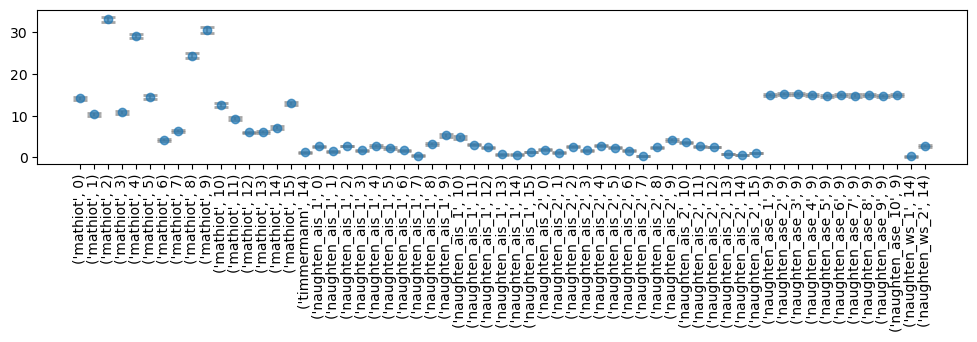

In [51]:
ds_stack = warm_target.stack(modelbasin=('model','basins')).dropna(dim='modelbasin')

plt.figure(figsize=(12,2))
plt.errorbar(range(len(ds_stack.modelbasin)), 
            ds_stack.melt_rate/ice_density, 
            xerr=None, yerr=ds_stack.melt_rate_uncert.dropna(dim='modelbasin')/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
plt.xticks(range(len(ds_stack.modelbasin.values)),ds_stack.modelbasin.values, rotation=90)

In [52]:
cold_target.to_netcdf(os.path.join(data_path, 'parameterisations',"melt_cold_target_term3.nc"))
warm_target.to_netcdf(os.path.join(data_path, 'parameterisations',"melt_warm_target_term3.nc"))


# melt target for term 4

In [23]:
# Datasets from publications

PIGtimes=np.array([1994,2007,2009,2010,2012,2014,2016,2019,2020])
PIGmelt=np.array([47.6,98.7,77.9,60.2,31.4,30.4,36.4,60.3,39.8])#in km3/yr
PIGmeltSTD=np.array([9.7,30.2,20.7,7.7,19.7,29.2,17.7,13.9,5.4])
#PIGWaterTemp=[1.82,2.03,2.11,2.22,1.43,1.92,1.42,1.89,1.99]
#PIGWaterTempSTD=[0.2,0.13,0.16,0.11,0.18,0.15,0.08,0.15,0.08]

DIStimes=np.array([2000,2006,2007,2009,2011,2012,2014,2016,2018])
DISmelt=np.array([26.2,68.9,39.4,82.5,55.7,23.5,20.5,26.5,17.1])#in km3/yr
DISmeltSTD=np.array([10.1,10.3,22.4,34.7,15.3,10.9,8.5,18,11.9])
#DISWaterTemp=[1.11,1.66,1.58,1.84,1.67,1.17,1.04,1.04,1.34];
#DISWaterTempSTD=[0.1,0.17,0.22,0.2,0.15,0.14,0.08,0.07,0.15];

In [24]:
da_pig = xr.DataArray(
    PIGmelt*910/1e3, #Gt/a
    dims=["year"],
    coords={"year": PIGtimes, "region": "pig"}
)

da_dotson = xr.DataArray(
    DISmelt*910/1e3, # Gt/a
    dims=["year"],
    coords={"year": DIStimes, "region": "dotson"}
)

da_unc_pig = xr.DataArray(
    PIGmeltSTD*910/1e3, #Gt/a
    dims=["year"],
    coords={"year": PIGtimes, "region": "pig"}
)
da_unc_dotson = xr.DataArray(
    DISmeltSTD*910/1e3, #Gt/a
    dims=["year"],
    coords={"year": DIStimes, "region": "dotson"}
)


# Concat each variable across regions
melt_combined = xr.concat([da_pig, da_dotson], dim="region")
unc_combined  = xr.concat([da_unc_pig, da_unc_dotson],  dim="region")

# Build dataset with both variables
t4_obs = xr.Dataset({
    "melt_rate":   melt_combined,
    "melt_rate_uncert": unc_combined,
})

<ErrorbarContainer object of 3 artists>

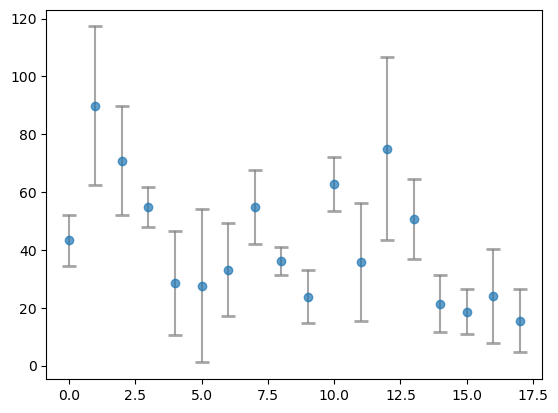

In [26]:
ds_stack = t4_obs.stack(region_year=('region','year')).dropna(dim='region_year')

plt.errorbar(range(len(ds_stack.region_year)), 
            ds_stack.melt_rate, 
            xerr=None, yerr=ds_stack.melt_rate_uncert.dropna(dim='region_year'), 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')

In [27]:
t4_obs.to_netcdf(os.path.join(data_path, 'parameterisations',"melt_observations_target_term4.nc"))